# Final Project Sains Data: Prediksi Harga Mobil

**Identitas**

- Nama: Febnawan Fatur Rochman
- NPM: 237006029
- Kelas: Informatika A
- Dataset: `Car_sales.xlsx`
- Metode utama: `LinearRegression`

Notebook ini saya gunakan untuk menganalisis data penjualan mobil. Fokusnya ada tiga: melihat mobil dengan penjualan tertinggi, membaca pola spesifikasinya, lalu membuat model prediksi harga berdasarkan fitur numerik yang tersedia di dataset.


## 1. Business Understanding

Saya memosisikan kasus ini seperti analisis sederhana untuk membaca pasar mobil. Pertanyaan yang ingin saya jawab:

1. mobil apa saja yang penjualannya paling tinggi,
2. spesifikasi seperti apa yang muncul pada mobil-mobil tersebut, dan
3. berapa perkiraan harga mobil jika spesifikasinya dimasukkan ke model.

Model utama yang digunakan adalah `LinearRegression` karena metode tersebut diminta pada instruksi tugas.


## 2. Data Understanding

Dataset berisi pabrikan, model mobil, jumlah penjualan, tipe kendaraan, harga, dan beberapa spesifikasi teknis. Sebelum data dibersihkan, saya cek dulu bentuk data, tipe kolom, statistik awal, dan missing value.


### 2.1 Import library

Library yang dipakai adalah `pandas`, `numpy`, `matplotlib`, `seaborn`, dan beberapa modul dari `scikit-learn`.


In [1]:
import importlib
import os
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
}

missing_packages = []
for import_name, package_name in required_packages.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        missing_packages.append(package_name)

running_in_colab = "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ
if missing_packages and running_in_colab:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
elif missing_packages:
    print(
        "Package belum tersedia di environment lokal:",
        missing_packages,
        "- install requirements.txt di virtualenv, atau jalankan cell ini di Google Colab.",
    )
else:
    print("Semua package utama tersedia.")


Semua package utama tersedia.


In [2]:
from pathlib import Path
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


### 2.2 Load data

Data dibaca dari file `Car_sales.xlsx`. Path dibuat relatif agar notebook bisa dijalankan dari repo maupun Google Colab.


In [3]:
def find_dataset_path() -> Path:
    """Find Car_sales.xlsx from common local/Colab locations."""
    candidates = [
        Path("data/raw/Car_sales.xlsx"),
        Path("../data/raw/Car_sales.xlsx"),
        Path("/content/Car_sales.xlsx"),
        Path("Car_sales.xlsx"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    try:
        from google.colab import files  # type: ignore

        print("Upload file Car_sales.xlsx karena dataset belum ditemukan di path relatif.")
        uploaded = files.upload()
        if "Car_sales.xlsx" in uploaded:
            return Path("Car_sales.xlsx")
    except Exception:
        pass

    raise FileNotFoundError(
        "Car_sales.xlsx tidak ditemukan. Letakkan file di data/raw/Car_sales.xlsx "
        "atau upload file saat menjalankan notebook di Colab."
    )


data_path = find_dataset_path()
df_raw = pd.read_excel(data_path, sheet_name="Car_sales")
print(f"Dataset path: {data_path}")
print(f"Shape dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")


Dataset path: data/raw/Car_sales.xlsx
Shape dataset: 157 baris x 16 kolom


### 2.3 Melihat data

Saya cek `head`, `info`, dan `describe` supaya tahu isi data sebelum mulai cleaning.


In [4]:
display(df_raw.head())


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2012-02-02 00:00:00,58.280
1,Acura,TL,39.384,19.875,Passenger,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,2011-03-06 00:00:00,91.371
2,Acura,CL,14.114,18.225,Passenger,NaN,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2012-04-01 00:00:00,NaN
3,Acura,RL,8.588,29.725,Passenger,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2011-10-03 00:00:00,91.390
4,Audi,A4,20.397,22.255,Passenger,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,2011-08-10 00:00:00,62.778


In [5]:
buffer = StringIO()
df_raw.info(buf=buffer)
print(buffer.getvalue())


<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    float64
dtypes

In [6]:
display(df_raw.describe(include="all"))


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
count,157,157,157.000,121.000,157,155.000,156.000,156.000,156.000,156.000,156.000,155.000,156.000,154.000,157,155.000
unique,30,156,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130,NaN
top,Dodge,Neon,NaN,NaN,Passenger,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-04-01 00:00:00,NaN
freq,11,2,NaN,NaN,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
mean,NaN,NaN,52.998,18.073,NaN,27.391,3.061,185.949,107.487,71.150,187.344,3.378,17.952,23.844,NaN,77.044
std,NaN,NaN,68.029,11.453,NaN,14.352,1.045,56.700,7.641,3.452,13.432,0.631,3.888,4.283,NaN,25.143
min,NaN,NaN,0.110,5.160,NaN,9.235,1.000,55.000,92.600,62.600,149.400,1.895,10.300,15.000,NaN,23.276
25%,NaN,NaN,14.114,11.260,NaN,18.017,2.300,149.500,103.000,68.400,177.575,2.971,15.800,21.000,NaN,60.408
50%,NaN,NaN,29.450,14.180,NaN,22.799,3.000,177.500,107.000,70.550,187.900,3.342,17.200,24.000,NaN,72.031
75%,NaN,NaN,67.956,19.875,NaN,31.947,3.575,215.000,112.200,73.425,196.125,3.800,19.575,26.000,NaN,89.415


Dari pengecekan awal, dataset memiliki 157 baris dan 16 kolom. Kolomnya campuran antara kategori seperti `Manufacturer`, `Model`, `Vehicle_type`, dan numerik seperti penjualan, harga, ukuran mesin, horsepower, serta konsumsi bahan bakar. Target prediksi yang digunakan adalah `Price_in_thousands`.


### 2.4 Audit missing value sebelum cleaning

Missing value dicek dulu supaya jelas kolom mana yang perlu dihapus atau diisi.


In [7]:
missing_before = (
    df_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda table: table["missing_count"] / len(df_raw) * 100)
)
missing_before = missing_before[missing_before["missing_count"] > 0]
display(missing_before)


,missing_count,missing_percent
__year_resale_value,36,22.930
Price_in_thousands,2,1.274
Engine_size,1,0.637
Horsepower,1,0.637
Wheelbase,1,0.637
Width,1,0.637
Length,1,0.637
Curb_weight,2,1.274
Fuel_capacity,1,0.637
Fuel_efficiency,3,1.911


Kolom yang paling banyak kosong adalah `__year_resale_value`. Target `Price_in_thousands` juga memiliki missing value, sehingga baris tersebut saya hapus dari data modeling karena harga aktualnya tidak diketahui.


## 3. Data Preparation

Pada bagian ini saya menyiapkan data untuk model. Baris dengan target kosong dihapus, lalu missing value pada fitur numerik ditangani dengan median dari data training.


### 3.1 Menghapus missing value pada target

Baris dengan `Price_in_thousands` kosong dihapus. Kalau targetnya diisi manual, hasil evaluasi model bisa jadi tidak jujur.


In [8]:
TARGET = "Price_in_thousands"
CANDIDATE_NUMERIC_FEATURES = [
    "Engine_size",
    "Horsepower",
    "Wheelbase",
    "Width",
    "Length",
    "Curb_weight",
    "Fuel_capacity",
    "Fuel_efficiency",
    "Power_perf_factor",
]
EXCLUDED_PROXY_FEATURES = ["Power_perf_factor"]
NUMERIC_FEATURES = [feature for feature in CANDIDATE_NUMERIC_FEATURES if feature not in EXCLUDED_PROXY_FEATURES]
CATEGORICAL_COLUMNS = ["Manufacturer", "Model", "Vehicle_type"]

rows_before_drop = len(df_raw)
target_missing_count = int(df_raw[TARGET].isna().sum())

df_clean = df_raw.dropna(subset=[TARGET]).copy()
rows_after_drop = len(df_clean)

drop_summary = pd.DataFrame(
    {
        "step": ["before_drop", "target_missing", "after_drop"],
        "row_count": [rows_before_drop, target_missing_count, rows_after_drop],
    }
)
feature_schema_summary = pd.DataFrame(
    {
        "schema": ["candidate_numeric_features", "excluded_proxy_features", "final_model_features"],
        "count": [len(CANDIDATE_NUMERIC_FEATURES), len(EXCLUDED_PROXY_FEATURES), len(NUMERIC_FEATURES)],
        "columns": [
            ", ".join(CANDIDATE_NUMERIC_FEATURES),
            ", ".join(EXCLUDED_PROXY_FEATURES),
            ", ".join(NUMERIC_FEATURES),
        ],
    }
)

display(drop_summary)
display(feature_schema_summary)


,step,row_count
0,before_drop,157
1,target_missing,2
2,after_drop,155


,schema,count,columns
0,candidate_numeric_features,9,"Engine_size, Horsepower, Wheelbase, Width, Len..."
1,excluded_proxy_features,1,Power_perf_factor
2,final_model_features,8,"Engine_size, Horsepower, Wheelbase, Width, Len..."


Setelah baris dengan target kosong dihapus, data masih memiliki missing value pada beberapa fitur. Nilai kosong tersebut ditangani pada langkah berikutnya.


### 3.2 Mengisi missing value pada fitur

Fitur numerik diisi dengan median. Saya memilih median karena nilainya lebih tahan terhadap data yang terlalu ekstrem dibandingkan rata-rata.


In [9]:
missing_after_drop_before_impute = df_clean[NUMERIC_FEATURES + CATEGORICAL_COLUMNS].isna().sum()

missing_preparation_summary = pd.DataFrame(
    {
        "missing_after_target_drop": missing_after_drop_before_impute,
        "used_in_model": [column in NUMERIC_FEATURES for column in NUMERIC_FEATURES + CATEGORICAL_COLUMNS],
    }
)
display(missing_preparation_summary)

print(
    "Fitur numerik yang masih kosong tidak diisi pada seluruh dataset. "
    "Median akan dihitung hanya dari X_train setelah train/test split agar tidak terjadi data leakage."
)


,missing_after_target_drop,used_in_model
Engine_size,0,True
Horsepower,0,True
Wheelbase,0,True
Width,0,True
Length,0,True
Curb_weight,1,True
Fuel_capacity,0,True
Fuel_efficiency,2,True
Manufacturer,0,False
Model,0,False


Fitur numerik yang masih kosong tidak diisi pada seluruh dataset. Median akan dihitung hanya dari X_train setelah train/test split agar tidak terjadi data leakage.


Untuk menghindari data leakage, median dihitung dari data training saja setelah split 80:20. Median yang sama kemudian digunakan untuk data testing dan input prediksi baru.


### 3.3 Audit korelasi dan fitur proxy

Sebelum model final dibuat, saya cek korelasi fitur numerik terhadap target. `Power_perf_factor` tetap saya audit, tetapi tidak saya gunakan pada model final karena nilainya terlalu dekat dengan harga dan membuat evaluasi terlihat hampir sempurna pada dataset kecil.


In [10]:
correlation_candidates = [
    column
    for column in [*CANDIDATE_NUMERIC_FEATURES, "__year_resale_value", "Sales_in_thousands"]
    if column in df_clean.columns
]

correlation_table = (
    df_clean[[TARGET, *correlation_candidates]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .rename("correlation_with_price")
    .to_frame()
)
correlation_table["absolute_correlation"] = correlation_table["correlation_with_price"].abs()
display(correlation_table)


def evaluate_feature_set(feature_columns: list[str], label: str) -> dict[str, float | str | int]:
    X_eval = df_clean[feature_columns].copy()
    y_eval = df_clean[TARGET].copy()
    X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
        X_eval,
        y_eval,
        test_size=0.20,
        random_state=42,
    )
    medians_eval = X_train_eval.median(numeric_only=True)
    model_eval = LinearRegression()
    model_eval.fit(X_train_eval.fillna(medians_eval), y_train_eval)
    pred_eval = model_eval.predict(X_test_eval.fillna(medians_eval))

    cv_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LinearRegression()),
        ]
    )
    cv_rmse = -cross_val_score(
        cv_pipeline,
        X_eval,
        y_eval,
        cv=5,
        scoring="neg_root_mean_squared_error",
    )
    return {
        "feature_set": label,
        "feature_count": len(feature_columns),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test_eval, pred_eval))),
        "test_r2": float(r2_score(y_test_eval, pred_eval)),
        "cv_rmse_mean": float(cv_rmse.mean()),
        "cv_rmse_std": float(cv_rmse.std()),
    }

proxy_comparison = pd.DataFrame(
    [
        evaluate_feature_set(CANDIDATE_NUMERIC_FEATURES, "candidate_with_power_perf_factor"),
        evaluate_feature_set(NUMERIC_FEATURES, "final_without_power_perf_factor"),
    ]
)
display(proxy_comparison)


,correlation_with_price,absolute_correlation
__year_resale_value,0.954,0.954
Power_perf_factor,0.898,0.898
Horsepower,0.840,0.840
Engine_size,0.627,0.627
Curb_weight,0.526,0.526
Fuel_efficiency,-0.492,0.492
Fuel_capacity,0.423,0.423
Width,0.329,0.329
Sales_in_thousands,-0.305,0.305
Length,0.157,0.157


,feature_set,feature_count,test_rmse,test_r2,cv_rmse_mean,cv_rmse_std
0,candidate_with_power_perf_factor,9,0.000,1.000,0.000,0.000
1,final_without_power_perf_factor,8,7.389,0.746,7.134,1.755


Hasil perbandingan menunjukkan bahwa `Power_perf_factor` membuat skor test set hampir sempurna. Karena itu model final memakai delapan fitur spesifikasi fisik dan efisiensi, tanpa `Power_perf_factor`, supaya hasilnya lebih masuk akal sebagai baseline akademik.


## 4. Exploratory Data Analysis

EDA saya fokuskan pada 10 model dengan penjualan tertinggi. Bagian ini menampilkan jumlah penjualan, harga, dan beberapa atribut teknis dari mobil-mobil yang paling laku di dataset.


In [11]:
top10_sales = (
    df_raw.sort_values("Sales_in_thousands", ascending=False)
    .head(10)
    .copy()
)
top10_sales["Car"] = top10_sales["Manufacturer"] + " " + top10_sales["Model"]

display(
    top10_sales[
        [
            "Manufacturer",
            "Model",
            "Vehicle_type",
            "Sales_in_thousands",
            "Price_in_thousands",
            "Engine_size",
            "Horsepower",
            "Fuel_efficiency",
        ]
    ]
)


,Manufacturer,Model,Vehicle_type,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_efficiency
56,Ford,F-Series,Car,540.561,26.935,4.600,220.000,18.000
52,Ford,Explorer,Car,276.747,31.930,4.000,210.000,19.000
137,Toyota,Camry,Passenger,247.994,17.518,2.200,133.000,27.000
49,Ford,Taurus,Passenger,245.815,17.885,3.000,155.000,24.000
58,Honda,Accord,Passenger,230.902,15.350,2.300,135.000,27.000
40,Dodge,Ram Pickup,Car,227.061,19.460,5.200,230.000,17.000
55,Ford,Ranger,Car,220.650,12.050,2.500,119.000,23.000
57,Honda,Civic,Passenger,199.685,12.885,1.600,106.000,32.000
45,Dodge,Caravan,Car,181.749,19.565,2.400,150.000,24.000
50,Ford,Focus,Passenger,175.670,12.315,2.000,107.000,30.000


### 4.1 Chart 10 Jenis Mobil dengan Penjualan Terbanyak

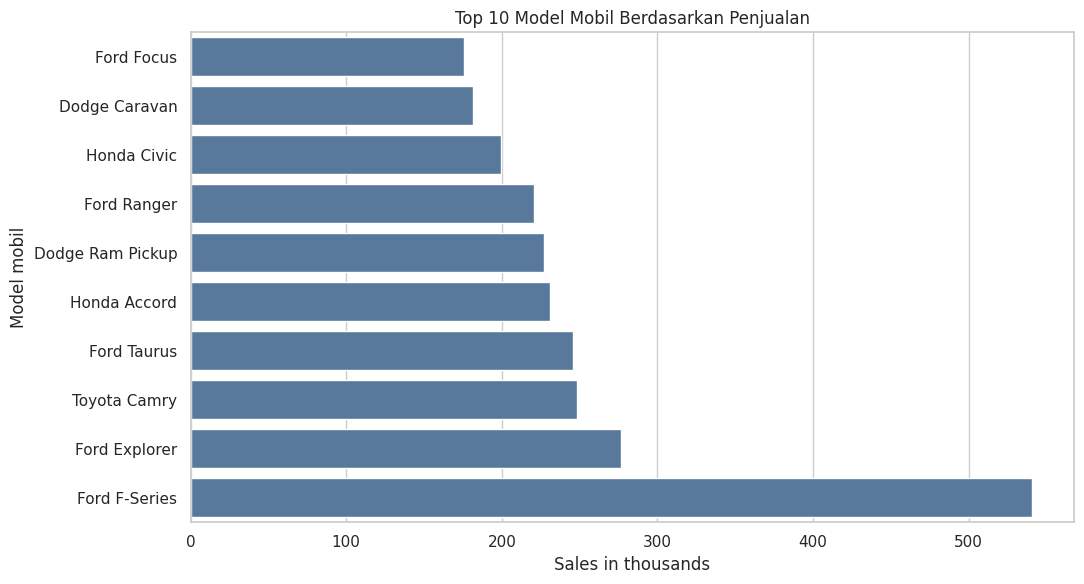

In [12]:
plt.figure(figsize=(11, 6))
sales_plot_data = top10_sales.sort_values("Sales_in_thousands", ascending=True)
sns.barplot(data=sales_plot_data, x="Sales_in_thousands", y="Car", color="#4C78A8")
plt.title("Top 10 Model Mobil Berdasarkan Penjualan")
plt.xlabel("Sales in thousands")
plt.ylabel("Model mobil")
plt.tight_layout()
plt.show()


Ford F-Series menjadi model dengan penjualan tertinggi, yaitu 540.561 dalam satuan ribuan. Setelah itu ada Ford Explorer, Toyota Camry, Ford Taurus, dan Honda Accord. Top 10 ini tidak hanya berisi sedan, tetapi juga truck dan SUV.


### 4.2 Harga dari 10 Jenis Mobil dengan Penjualan Terbanyak

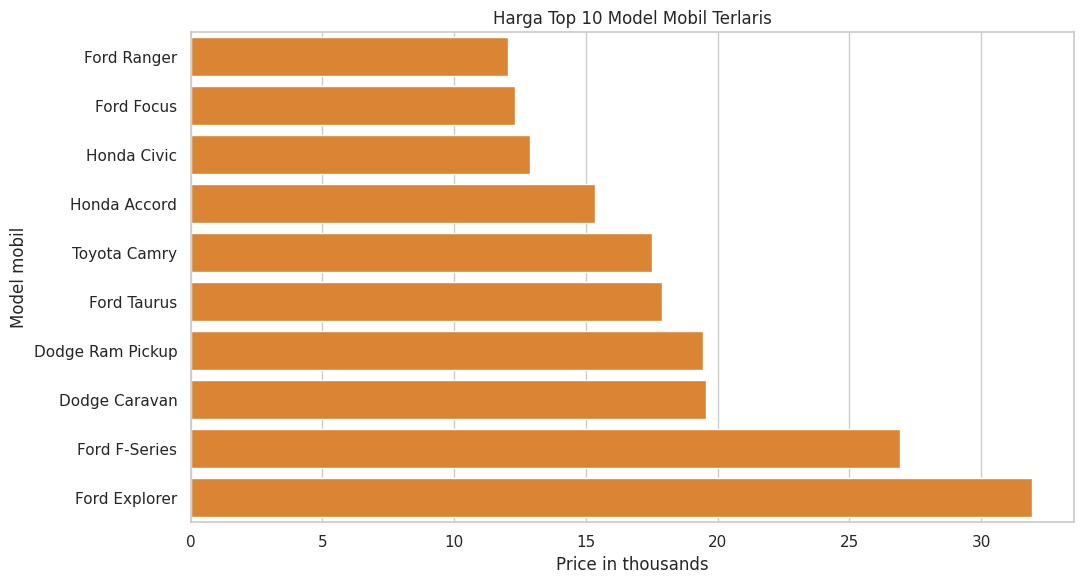

,Car,Sales_in_thousands,Price_in_thousands
56,Ford F-Series,540.561,26.935
52,Ford Explorer,276.747,31.930
137,Toyota Camry,247.994,17.518
49,Ford Taurus,245.815,17.885
58,Honda Accord,230.902,15.350
40,Dodge Ram Pickup,227.061,19.460
55,Ford Ranger,220.650,12.050
57,Honda Civic,199.685,12.885
45,Dodge Caravan,181.749,19.565
50,Ford Focus,175.670,12.315


In [13]:
plt.figure(figsize=(11, 6))
price_plot_data = top10_sales.sort_values("Price_in_thousands", ascending=True)
sns.barplot(data=price_plot_data, x="Price_in_thousands", y="Car", color="#F58518")
plt.title("Harga Top 10 Model Mobil Terlaris")
plt.xlabel("Price in thousands")
plt.ylabel("Model mobil")
plt.tight_layout()
plt.show()

display(top10_sales[["Car", "Sales_in_thousands", "Price_in_thousands"]])


Harga mobil top 10 tidak selalu berada di kelompok murah. Ford Explorer termasuk yang paling mahal di daftar ini, sedangkan Ford Ranger, Honda Civic, dan Ford Focus berada di harga yang lebih rendah. Jadi, penjualan tinggi tidak otomatis berarti harga paling murah.


### 4.3 Atribut Lain pada Top 10: Engine Size, Horsepower, dan Fuel Efficiency

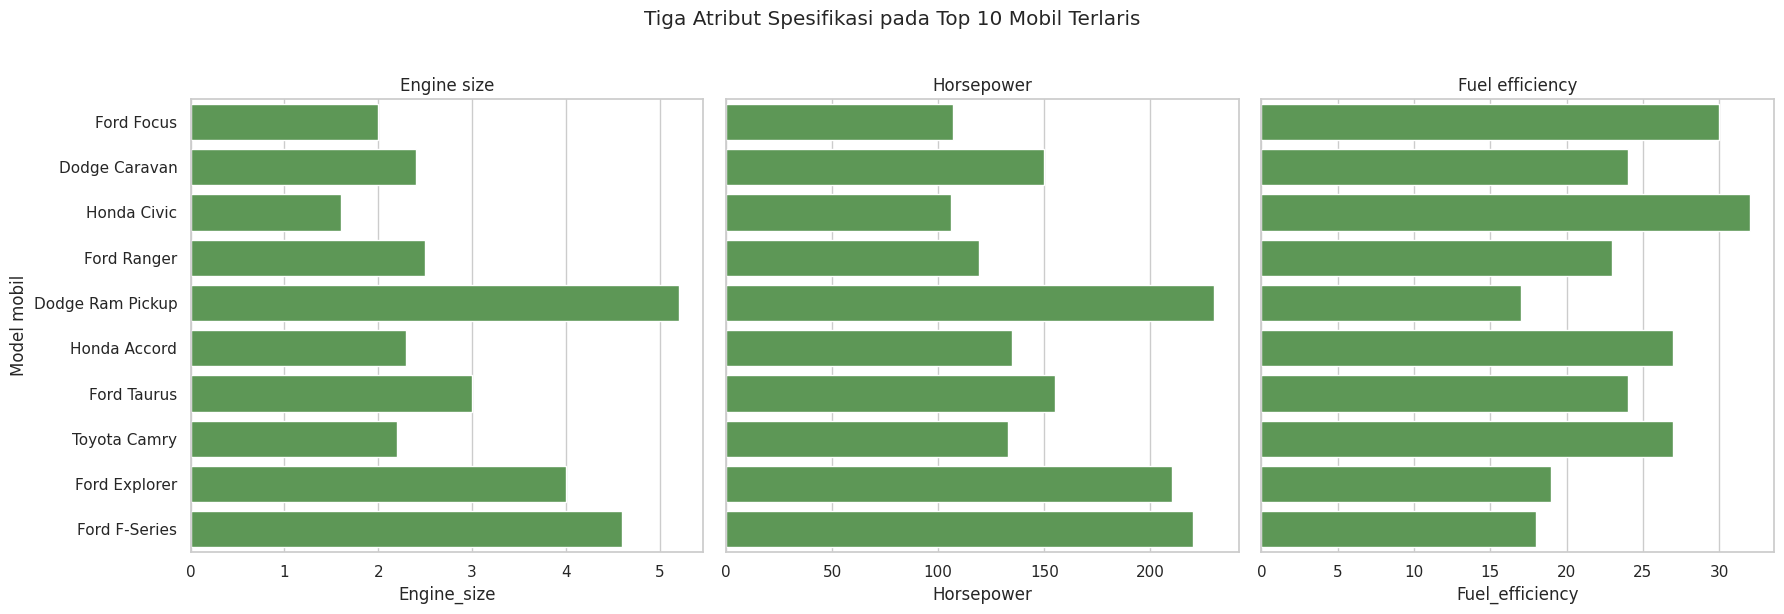

,Car,Vehicle_type,Engine_size,Horsepower,Fuel_efficiency
56,Ford F-Series,Car,4.600,220.000,18.000
52,Ford Explorer,Car,4.000,210.000,19.000
137,Toyota Camry,Passenger,2.200,133.000,27.000
49,Ford Taurus,Passenger,3.000,155.000,24.000
58,Honda Accord,Passenger,2.300,135.000,27.000
40,Dodge Ram Pickup,Car,5.200,230.000,17.000
55,Ford Ranger,Car,2.500,119.000,23.000
57,Honda Civic,Passenger,1.600,106.000,32.000
45,Dodge Caravan,Car,2.400,150.000,24.000
50,Ford Focus,Passenger,2.000,107.000,30.000


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
attribute_specs = [
    ("Engine_size", "Engine size"),
    ("Horsepower", "Horsepower"),
    ("Fuel_efficiency", "Fuel efficiency"),
]
ordered_top10 = top10_sales.sort_values("Sales_in_thousands", ascending=True)

for axis, (column, title) in zip(axes, attribute_specs):
    sns.barplot(data=ordered_top10, x=column, y="Car", ax=axis, color="#54A24B")
    axis.set_title(title)
    axis.set_xlabel(column)
    axis.set_ylabel("" if axis is not axes[0] else "Model mobil")

plt.suptitle("Tiga Atribut Spesifikasi pada Top 10 Mobil Terlaris", y=1.02)
plt.tight_layout()
plt.show()

display(top10_sales[["Car", "Vehicle_type", "Engine_size", "Horsepower", "Fuel_efficiency"]])


Dari atribut teknis, truck/SUV seperti Ford F-Series dan Dodge Ram Pickup memiliki ukuran mesin dan horsepower yang lebih besar. Honda Civic dan Ford Focus lebih kecil dan lebih hemat bahan bakar. Ini menunjukkan bahwa mobil terlaris di dataset punya karakter yang cukup beragam.


## 5. Rekomendasi spesifikasi mobil

Rekomendasi spesifikasi diambil dari median 10 mobil dengan penjualan tertinggi. Saya memakai median agar hasilnya tidak terlalu ditarik oleh satu mobil yang nilainya ekstrem.


In [15]:
feature_rationale = pd.DataFrame(
    {
        "variable": NUMERIC_FEATURES,
        "reason": [
            "Ukuran mesin memengaruhi performa dan segmen kendaraan.",
            "Tenaga mesin berhubungan dengan daya tarik performa.",
            "Wheelbase menggambarkan ukuran dan stabilitas kendaraan.",
            "Width membantu merepresentasikan dimensi kendaraan.",
            "Length membantu membedakan compact, sedan, SUV, dan truck.",
            "Curb weight menggambarkan bobot kendaraan yang terkait performa dan konsumsi.",
            "Fuel capacity berkaitan dengan jangkauan penggunaan kendaraan.",
            "Fuel efficiency penting untuk biaya operasional konsumen.",
        ],
    }
)
display(feature_rationale)

recommended_specs = top10_sales[NUMERIC_FEATURES].median(numeric_only=True).to_frame().T
recommended_specs.insert(0, "Vehicle_type_mode_top10", top10_sales["Vehicle_type"].mode().iloc[0])
display(recommended_specs)


,variable,reason
0,Engine_size,Ukuran mesin memengaruhi performa dan segmen k...
1,Horsepower,Tenaga mesin berhubungan dengan daya tarik per...
2,Wheelbase,Wheelbase menggambarkan ukuran dan stabilitas ...
3,Width,Width membantu merepresentasikan dimensi kenda...
4,Length,"Length membantu membedakan compact, sedan, SUV..."
5,Curb_weight,Curb weight menggambarkan bobot kendaraan yang...
6,Fuel_capacity,Fuel capacity berkaitan dengan jangkauan pengg...
7,Fuel_efficiency,Fuel efficiency penting untuk biaya operasiona...


,Vehicle_type_mode_top10,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,Car,2.450,142.500,110.050,70.250,189.750,3.227,19.250,24.000


Spesifikasi median dari top 10 dipakai sebagai contoh mobil rekomendasi. `Vehicle_type` tetap ditampilkan sebagai informasi tambahan, tetapi model prediksi harga hanya memakai fitur numerik.


## 6. Modeling

Model yang digunakan adalah `LinearRegression`. Targetnya adalah `Price_in_thousands`, sedangkan fitur inputnya terdiri dari spesifikasi numerik seperti engine size, horsepower, wheelbase, dimensi, berat, kapasitas bahan bakar, dan fuel efficiency.


### 6.1 Feature/Target Split

In [16]:
X = df_clean[NUMERIC_FEATURES].copy()
y = df_clean[TARGET].copy()

print("Variabel independen:", list(X.columns))
print("Variabel dependen:", TARGET)
print("X shape before imputation:", X.shape)
print("y shape:", y.shape)
print("Missing fitur sebelum split:")
display(X.isna().sum().rename("missing_count").to_frame())


Variabel independen: ['Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']
Variabel dependen: Price_in_thousands
X shape before imputation: (155, 8)
y shape: (155,)
Missing fitur sebelum split:


,missing_count
Engine_size,0
Horsepower,0
Wheelbase,0
Width,0
Length,0
Curb_weight,1
Fuel_capacity,0
Fuel_efficiency,2


### 6.2 Train/Test Split 80:20

In [17]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

train_numeric_medians = X_train_raw[NUMERIC_FEATURES].median(numeric_only=True)
X_train = X_train_raw.fillna(train_numeric_medians)
X_test = X_test_raw.fillna(train_numeric_medians)

split_summary = pd.DataFrame(
    {
        "subset": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "percentage": [len(X_train) / len(X) * 100, len(X_test) / len(X) * 100],
        "missing_after_train_median_impute": [int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum())],
    }
)
display(split_summary)
display(train_numeric_medians.rename("train_median_used_for_imputation").to_frame())


,subset,rows,percentage,missing_after_train_median_impute
0,train,124,80.000,0
1,test,31,20.000,0


,train_median_used_for_imputation
Engine_size,3.000
Horsepower,175.000
Wheelbase,107.200
Width,70.400
Length,188.250
Curb_weight,3.368
Fuel_capacity,17.900
Fuel_efficiency,24.000


### 6.3 Membuat Model Regresi Linear

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coefficients = pd.DataFrame(
    {
        "feature": NUMERIC_FEATURES,
        "coefficient": model.coef_,
    }
).sort_values("coefficient", key=lambda series: series.abs(), ascending=False)

print(f"Intercept: {model.intercept_:.3f}")
display(coefficients)


Intercept: 26.034


,feature,coefficient
5,Curb_weight,6.923
0,Engine_size,-4.573
3,Width,-0.614
7,Fuel_efficiency,0.455
6,Fuel_capacity,0.435
1,Horsepower,0.277
4,Length,-0.221
2,Wheelbase,0.063


Koefisien model menunjukkan arah hubungan fitur dengan harga. Karena skala setiap fitur berbeda, angka koefisien tidak langsung saya anggap sebagai urutan fitur terpenting. Model final sengaja tidak memakai `Power_perf_factor` agar hasil evaluasi tidak bergantung pada fitur proxy yang terlalu dekat dengan harga.


## 7. Evaluation

Model dievaluasi memakai data testing saja. Metrik yang dipakai adalah RMSE dan R2 Score, sesuai instruksi tugas.


In [19]:
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = float(r2_score(y_test, y_pred))

final_cv_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LinearRegression()),
    ]
)
cv_rmse_scores = -cross_val_score(
    final_cv_pipeline,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
)

metrics = pd.DataFrame(
    {
        "metric": ["RMSE", "R2 Score", "CV RMSE Mean", "CV RMSE Std"],
        "value": [rmse, r2, float(cv_rmse_scores.mean()), float(cv_rmse_scores.std())],
    }
)
display(metrics)


,metric,value
0,RMSE,7.389
1,R2 Score,0.746
2,CV RMSE Mean,7.134
3,CV RMSE Std,1.755


RMSE dibaca dalam satuan ribuan dolar. R2 Score menunjukkan seberapa jauh fitur yang dipakai dapat menjelaskan harga pada data testing. Karena `Power_perf_factor` dikeluarkan dari model final, hasil evaluasi menjadi lebih realistis untuk baseline: model masih bisa menjelaskan sebagian besar variasi harga, tetapi error-nya tetap perlu diperhatikan.


### 7.1 Scatter Plot Actual vs Predicted

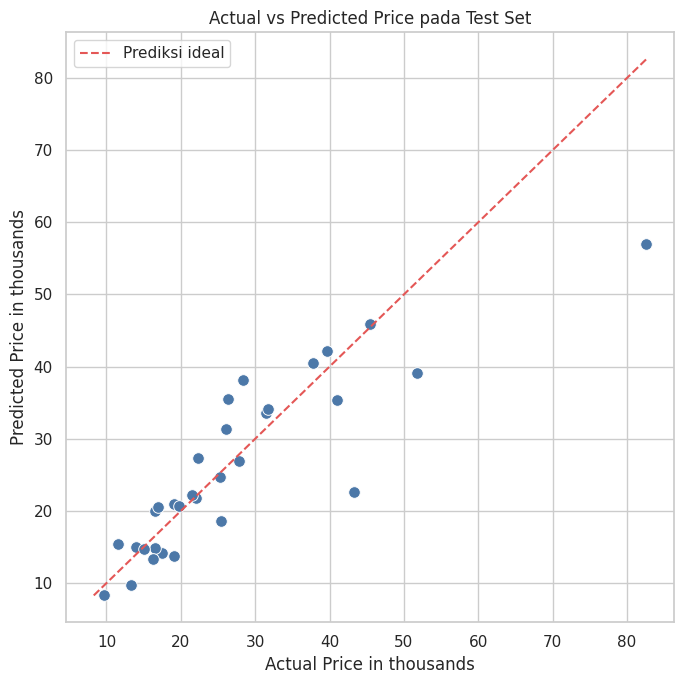

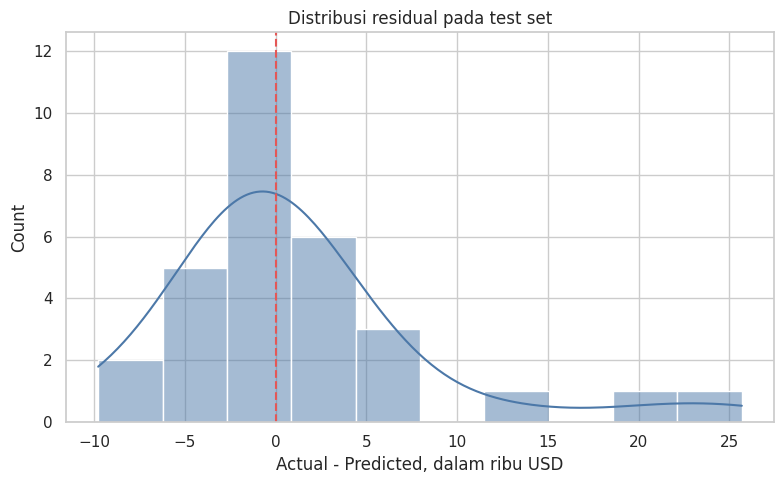

,actual_price,predicted_price,residual
83,25.450,18.540,6.910
144,51.728,39.103,12.625
32,28.340,38.116,-9.776
30,22.245,27.381,-5.136
120,25.310,24.750,0.560
62,9.699,8.290,1.409
95,82.600,56.920,25.680
149,17.500,14.220,3.280
155,45.500,45.945,-0.445
70,31.505,33.597,-2.092


,residual_summary
count,31.000
mean,1.176
std,7.416
min,-9.776
25%,-2.542
50%,-0.445
75%,3.085
max,25.680


In [20]:
evaluation_df = pd.DataFrame(
    {
        "actual_price": y_test,
        "predicted_price": y_pred,
    }
)
evaluation_df["residual"] = evaluation_df["actual_price"] - evaluation_df["predicted_price"]

plt.figure(figsize=(7, 7))
sns.scatterplot(data=evaluation_df, x="actual_price", y="predicted_price", s=70, color="#4C78A8")
min_value = min(evaluation_df["actual_price"].min(), evaluation_df["predicted_price"].min())
max_value = max(evaluation_df["actual_price"].max(), evaluation_df["predicted_price"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="#E45756", linestyle="--", label="Prediksi ideal")
plt.title("Actual vs Predicted Price pada Test Set")
plt.xlabel("Actual Price in thousands")
plt.ylabel("Predicted Price in thousands")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(evaluation_df["residual"], kde=True, color="#4C78A8")
plt.axvline(0, color="#E45756", linestyle="--")
plt.title("Distribusi residual pada test set")
plt.xlabel("Actual - Predicted, dalam ribu USD")
plt.tight_layout()
plt.show()

display(evaluation_df.head(10))
display(evaluation_df["residual"].describe().rename("residual_summary").to_frame())


Pada scatter plot, titik yang dekat dengan garis putus-putus berarti prediksinya dekat dengan harga asli. Plot residual saya gunakan untuk melihat sebaran error. Karena dataset hanya 157 baris dan fiturnya terbatas, error beberapa ribu dolar masih wajar untuk baseline `LinearRegression`.


## 8. Prediksi harga dari dataframe spesifikasi baru

Setelah model dibuat, saya coba memasukkan spesifikasi rekomendasi ke dalam `DataFrame` baru. Kolomnya dibuat sama persis dengan fitur training.


In [21]:
new_car_input = recommended_specs[NUMERIC_FEATURES].copy()
new_car_input_imputed = new_car_input.fillna(train_numeric_medians)
predicted_price = float(model.predict(new_car_input_imputed)[0])
predicted_lower = max(0.0, predicted_price - rmse)
predicted_upper = predicted_price + rmse

prediction_result = new_car_input.copy()
prediction_result["Predicted_Price_in_thousands"] = predicted_price
prediction_result["Estimated_Lower_RMSE"] = predicted_lower
prediction_result["Estimated_Upper_RMSE"] = predicted_upper
prediction_result["Predicted_Price_USD_approx"] = predicted_price * 1000

display(prediction_result)
print(f"Prediksi harga mobil rekomendasi: {predicted_price:.3f} ribu USD")
print(f"Rentang kasar berbasis RMSE: {predicted_lower:.3f} - {predicted_upper:.3f} ribu USD")
print(f"Perkiraan nilai dolar: USD {predicted_price * 1000:,.0f}")


,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Predicted_Price_in_thousands,Estimated_Lower_RMSE,Estimated_Upper_RMSE,Predicted_Price_USD_approx
0,2.450,142.500,110.050,70.250,189.750,3.227,19.250,24.000,17.761,10.371,25.150,"17,760.758"


Prediksi harga mobil rekomendasi: 17.761 ribu USD
Rentang kasar berbasis RMSE: 10.371 - 25.150 ribu USD
Perkiraan nilai dolar: USD 17,761


Hasil prediksi ini adalah estimasi harga untuk spesifikasi rekomendasi dari top 10 mobil terlaris. Saya juga menampilkan rentang kasar berbasis RMSE agar output tidak dibaca sebagai angka pasti.


## 9. Deployment web app

Selain notebook, model juga saya buat dalam bentuk aplikasi web sederhana memakai FastAPI, HTML, CSS, dan JavaScript. Backend menggunakan fitur dan preprocessing yang sama dengan notebook.

Aplikasi web bisa diakses di:

[https://car-ds.aquarise.my.id/](https://car-ds.aquarise.my.id/)


## 10. Kesimpulan dan keterbatasan

Kesimpulan singkat:

1. Ford F-Series menjadi mobil dengan penjualan tertinggi di dataset.
2. Mobil terlaris tidak selalu mobil yang paling murah. Ford Explorer tetap masuk top 10 meskipun harganya lebih tinggi dibanding beberapa model lain.
3. Spesifikasi rekomendasi dibuat dari median top 10 sales agar mewakili pola mobil yang banyak terjual.
4. Model `LinearRegression` final memakai delapan fitur numerik dan mengecualikan `Power_perf_factor` karena fitur tersebut terlalu kuat sebagai proxy harga.
5. Evaluasi memakai test set 20% dan cross-validation 5-fold, sehingga hasilnya lebih jujur daripada hanya menampilkan skor sangat tinggi dari fitur proxy.
6. Hasil prediksi ditampilkan bersama rentang kasar berbasis RMSE.

Keterbatasan:

- Dataset hanya memiliki 157 baris, jadi hasilnya belum bisa dianggap sebagai model produksi.
- Model linear belum tentu menangkap semua pola harga mobil.
- Banyak faktor penting tidak tersedia di dataset, misalnya kondisi mobil, fitur keselamatan, varian trim, dan tren pasar terbaru.
- Rentang error berbasis RMSE hanya estimasi kasar dari performa model pada data yang tersedia, bukan interval statistik formal.
